#**Project Overview**
This project analyzes Fashion Boutique retail data with a focus on **forecasting demand**, **evaluating pricing impact**, **understanding customer return behavior**, and **optimizing inventory management**. The workflow includes data extraction from Google BigQuery, feature encoding, exploratory data analysis (EDA), predictive modeling, and ABC inventory classification.

**Note**: Data cleaning and wrangling were already performed in *Google BigQuery*, so this notebook directly starts from the prepared dataset for analysis and modeling.

In [13]:
pip install google-cloud-bigquery db-dtypes

In [ ]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/retail-analysis-468900-7fc4757bbb7e.json"

In [ ]:
from google.cloud import bigquery
import os

# Upload file JSON to Colab
service_account_path = "/content/retail-analysis-468900-9216d37c5ad6.json"

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = service_account_path

# In. client
client = bigquery.Client(project="retail-analysis-468900")

# Query
query = """
SELECT *
FROM `retail-analysis-468900.Fashion_Boutique_2025.Final_Retail_Analysis_Data_Quarter`
LIMIT 10
"""
df = client.query(query).to_dataframe()
df.head()

,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date,stock_quantity,customer_rating,is_returned,return_reason,purchase_quarter
0,FB000892,Accessories,Forever21,Spring,None,Brown,64.56,43.0,36.80,2024-08-06,36,4.5903,False,None,Q3
1,FB002004,Dresses,Uniqlo,Spring,L,Purple,146.68,0.0,146.68,2024-08-07,8,0.0000,False,None,Q3
2,FB000496,Tops,Ann Taylor,Spring,None,Beige,51.69,33.4,34.43,2024-08-07,36,4.5750,False,None,Q3
3,FB000480,Shoes,Mango,Spring,XS,Pink,124.26,0.0,124.26,2024-08-08,44,4.0000,False,None,Q3
4,FB001048,Tops,Uniqlo,Spring,XS,Red,25.45,0.0,25.45,2024-08-10,29,4.5841,False,None,Q3


In [ ]:
# 1. IMPORT LIBRARIES
# ========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

##**1. Prophet Forecast**

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpu9prqxqc/o5kzqlw1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpu9prqxqc/6zpl35lt.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=65290', 'data', 'file=/tmp/tmpu9prqxqc/o5kzqlw1.json', 'init=/tmp/tmpu9prqxqc/6zpl35lt.json', 'output', 'file=/tmp/tmpu9prqxqc/prophet_modelnri9tanr/prophet_model-20250915065415.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:54:15 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:54:16 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


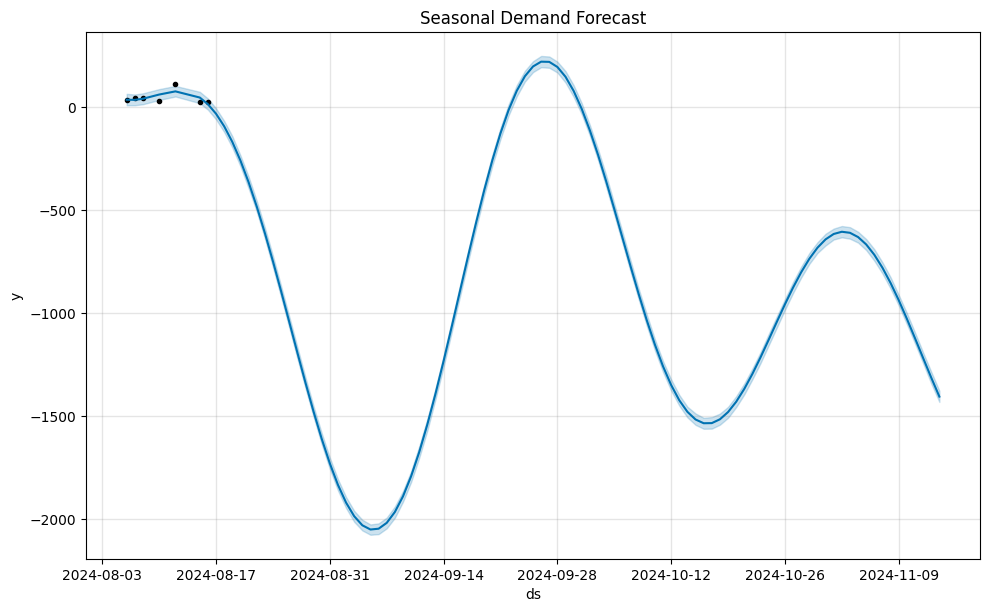

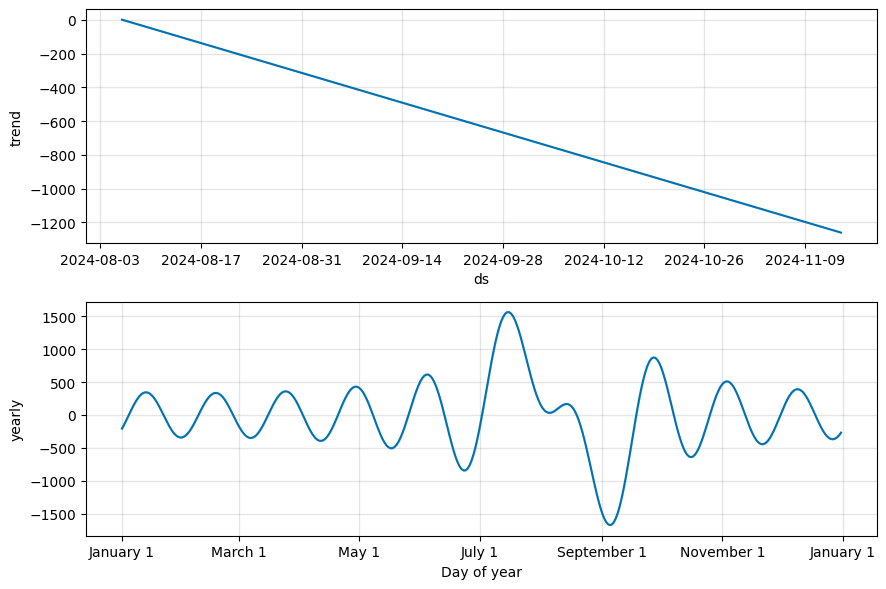

In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt

# Aggregate purchase quantity per date
ts = df.groupby('purchase_date')['stock_quantity'].sum().reset_index()
ts.columns = ['ds', 'y']

# Build model
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(ts)

# Forecast for the next 90 days
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Plot
model.plot(forecast)
plt.title("Seasonal Demand Forecast")
plt.show()

# Plot trend & seasonality components
model.plot_components(forecast)
plt.show()

###Prophet Forecast Insights
####Overall Forecast
1.   The demand shows significant short-term fluctuations, with sharp ups and downs across the 90-day horizon.
2.   This indicates that demand is not stable and requires close monitoring for inventory planning.

####Trend Component
1.   The long-term trend is declining, suggesting that overall demand may gradually decrease if no external factors change.
2.   This could signal potential market saturation or reduced purchasing activity.

####Seasonality Component
1.   Strong recurring seasonal patterns are observed, with clear peaks and troughs across the yearly cycle.
2.   Aligning inventory and marketing efforts with these cycles can help reduce overstocking and prevent stockouts.

##**2. OLS Regression on Markdown vs Return Rate**

In [ ]:
import statsmodels.api as sm

# Count return rate per price level
pricing_df = df.groupby('markdown_percentage')['is_returned'].mean().reset_index()

X = sm.add_constant(pricing_df['markdown_percentage'])
y = pricing_df['is_returned']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            is_returned   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                 -0.208
Method:                 Least Squares   F-statistic:                    0.1383
Date:                Thu, 28 Aug 2025   Prob (F-statistic):              0.729
Time:                        10:56:41   Log-Likelihood:                -2.3670
No. Observations:                   6   AIC:                             8.734
Df Residuals:                       4   BIC:                             8.317
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0628    

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


###OLS Regression on Markdown vs Return Rate Insights

1.   Examines the relationship between markdown percentage and return rates.
2.   If the regression coefficient is significantly positive, higher discounts may increase return rates—possibly due to lower perceived product quality when heavily discounted.

##**3. Boxplot: Customer Rating vs Return**

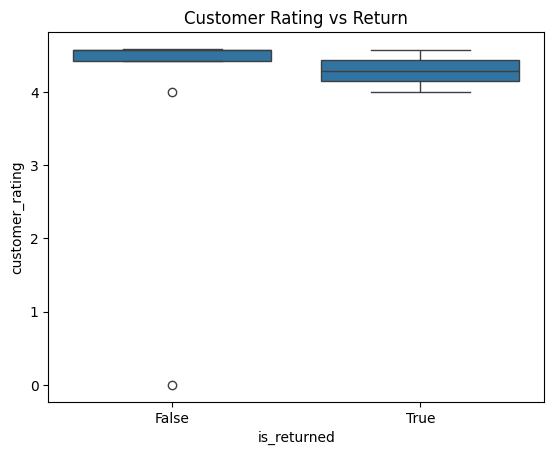

                 customer_rating  is_returned
customer_rating         1.000000     0.105147
is_returned             0.105147     1.000000


In [ ]:
import seaborn as sns

sns.boxplot(x='is_returned', y='customer_rating', data=df)
plt.title("Customer Rating vs Return")
plt.show()

# Rating & Return Classification
print(df[['customer_rating', 'is_returned']].corr())

###Boxplot: Customer Rating vs Return Insights

1.   Visualizes the distribution of ratings for returned vs. non-returned products.
2.   Lower-rated products are returned more frequently, confirming that customer satisfaction is closely tied to return behavior.

##**4. ABC Inventory Classification**

In [ ]:
inventory = df.groupby('product_id')['stock_quantity'].sum().reset_index()
inventory = inventory.sort_values(by='stock_quantity', ascending=False)

# Hitung cumulative share
inventory['cum_share'] = inventory['stock_quantity'].cumsum() / inventory['stock_quantity'].sum()

# ABC Classification
inventory['ABC'] = pd.cut(
    inventory['cum_share'],
    bins=[0, 0.7, 0.9, 1.0],
    labels=['A', 'B', 'C']
)

print(inventory.head(20))

  product_id  stock_quantity  cum_share ABC
7   FB001583              49   0.154088   A
1   FB000480              44   0.292453   A
8   FB001622              43   0.427673   A
2   FB000496              36   0.540881   A
3   FB000892              36   0.654088   A
4   FB001048              29   0.745283   B
0   FB000236              25   0.823899   B
6   FB001409              25   0.902516   C
5   FB001268              23   0.974843   C
9   FB002004               8        1.0   C


###ABC Inventory Classification Insights

1.   Groups products into A (high impact), B (medium), and C (low) categories based on cumulative stock share.
2.   A small subset of products (A class) contributes to the majority of inventory volume. Prioritizing these items can optimize warehouse management and reduce inefficiencies.

##**Overall Insights**

This analysis integrates forecasting, customer behavior analysis, pricing strategy evaluation, and inventory management into one workflow.

Key findings:

1.   **Forecasting**, The Prophet forecast reveals a declining overall demand trend with strong seasonal fluctuations, emphasizing the need for inventory and marketing strategies aligned to cyclical patterns.
2.   **Markdown strategy** directly impacts return behavior—excessive discounts may backfire.
3.   **Customer satisfaction (ratings)** strongly correlates with product returns.
4.   **Inventory segmentation (ABC analysis**) highlights that focusing on high-impact products can drive efficiency and profitability.